In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import seaborn as sns
import random

In [ ]:
data = pd.read_csv("electricity_consumption.csv")

In [ ]:
data

,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
0,01-Jan-20,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
1,01-Jan-20,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2,01-Jan-20,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
3,01-Jan-20,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
4,01-Jan-20,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
43843,31-Dec-24,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
43844,31-Dec-24,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
43845,31-Dec-24,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957
43846,31-Dec-24,22.0,1.0,12.0,2024.0,366.0,3.000000,51.998107,3353.241682


In [ ]:
# Informations about the DataSet
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Timestamp    43848 non-null  object 
 1   hour         43837 non-null  float64
 2   dayofweek    43839 non-null  float64
 3   month        43840 non-null  float64
 4   year         43843 non-null  float64
 5   dayofyear    43843 non-null  float64
 6   Temperature  43841 non-null  float64
 7   Humidity     43838 non-null  float64
 8   Demand       43841 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.0+ MB


In [ ]:
# Convert to time format
data["Timestamp"]=pd.to_datetime(data["Timestamp"])

/tmp/ipykernel_8492/1006842410.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Timestamp"]=pd.to_datetime(data["Timestamp"])


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Timestamp    43848 non-null  datetime64[ns]
 1   hour         43837 non-null  float64       
 2   dayofweek    43839 non-null  float64       
 3   month        43840 non-null  float64       
 4   year         43843 non-null  float64       
 5   dayofyear    43843 non-null  float64       
 6   Temperature  43841 non-null  float64       
 7   Humidity     43838 non-null  float64       
 8   Demand       43841 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 3.0 MB


In [ ]:
# Set datetime as dataframe index
data=data.set_index("Timestamp")

In [ ]:
data

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [ ]:
# Summary statistics
data.describe()

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
count,43837.000000,43839.000000,43840.000000,43843.000000,43843.000000,43841.000000,43838.000000,43841.000000
mean,11.499030,2.999795,6.521282,2022.000068,183.208654,25.067788,59.903007,5000.790976
std,6.922006,2.000051,3.449168,1.415044,105.478826,12.821725,18.342604,1412.527409
min,0.000000,0.000000,1.000000,2020.000000,1.000000,3.000000,20.000000,1611.954020
25%,5.000000,1.000000,4.000000,2021.000000,92.000000,15.210186,46.241224,4015.668472
50%,11.000000,3.000000,7.000000,2022.000000,183.000000,25.003212,59.986720,5013.053367
75%,17.000000,5.000000,10.000000,2023.000000,275.000000,34.740971,73.796820,6000.803082
max,23.000000,6.000000,12.000000,2024.000000,366.000000,50.000000,95.000000,11910.705100


In [ ]:
# Check for missing values

data.isnull().any()

,0
hour,True
dayofweek,True
month,True
year,True
dayofyear,True
Temperature,True
Humidity,True
Demand,True


In [ ]:
data.isnull().sum()

,0
hour,11
dayofweek,9
month,8
year,5
dayofyear,5
Temperature,7
Humidity,10
Demand,7


In [ ]:
# Show the records that contain null values

In [ ]:
data.isnull().any(axis=0)

,0
hour,True
dayofweek,True
month,True
year,True
dayofyear,True
Temperature,True
Humidity,True
Demand,True


In [ ]:
data[data.isnull().any(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-04-30,NaN,3.0,4.0,2020.0,121.0,21.820261,41.353675,5393.127681
2020-07-21,NaN,1.0,7.0,2020.0,203.0,36.555833,62.779665,6248.349423
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-27,NaN,5.0,2.0,2021.0,58.0,24.001003,53.303268,4523.253789
2021-12-13,23.0,0.0,12.0,2021.0,NaN,3.000000,75.457130,3225.225822
2021-12-14,NaN,1.0,12.0,2021.0,348.0,5.061319,47.215825,2887.848612


In [ ]:
# show records that contains all null values
data[data.isnull().all(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Drop records that contains all null values
data.dropna(how="all")

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [ ]:
# filling  missing values using  Backward Fill - bfill
# filling missing values using Forward Fill - ffill


In [ ]:
data[["hour","dayofweek","month","year","dayofyear"]]=data[["hour","dayofweek","month","year","dayofyear"]].ffill()

In [ ]:
data[["Temperature","Humidity"]]=data[["Temperature","Humidity"]].bfill()

In [ ]:
# fill in missing values by guessing based on nearby data using interpolate
data["Demand"]= data["Demand"].interpolate(method="time")

In [ ]:
data.isnull().sum()

,0
hour,0
dayofweek,0
month,0
year,0
dayofyear,0
Temperature,0
Humidity,0
Demand,0


In [ ]:
# Create the Quarter column

In [ ]:
data.insert(5,"Quarter",data.index.quarter)

In [ ]:
data

,hour,dayofweek,month,year,dayofyear,Quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,4,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,4,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,4,3.000000,40.565916,4015.979957


In [ ]:
# Convert datatype from float to int

data[["hour","dayofweek","month","year","dayofyear"]]=data[["hour","dayofweek","month","year","dayofyear"]].astype(int)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43848 entries, 2020-01-01 to 2024-12-31
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43848 non-null  int64  
 1   dayofweek    43848 non-null  int64  
 2   month        43848 non-null  int64  
 3   year         43848 non-null  int64  
 4   dayofyear    43848 non-null  int64  
 5   Quarter      43848 non-null  int32  
 6   Temperature  43848 non-null  float64
 7   Humidity     43848 non-null  float64
 8   Demand       43848 non-null  float64
dtypes: float64(3), int32(1), int64(5)
memory usage: 3.2 MB


In [ ]:
#Create weak of the year column

In [ ]:
data.insert(5,"weekofyear",data.index.isocalendar().week.astype(int))

In [ ]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,4,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,4,3.000000,40.565916,4015.979957


In [ ]:
# Create a new column to check weekend
data.insert(7,"is_weekend",data.index.dayofweek.isin([5,6]))

In [ ]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,False,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,False,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,False,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,False,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,False,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,False,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,4,False,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,4,False,3.000000,40.565916,4015.979957


In [ ]:
data["is_weekend"]=data["is_weekend"].astype(int)

In [ ]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957


In [ ]:
# import holiday package
import holidays

In [ ]:
data["holidays"]=holidays.MA(years=data.year)

In [ ]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand,holidays
Timestamp,,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872,New Year's Day
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712,New Year's Day
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403,New Year's Day
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413,New Year's Day
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006,New Year's Day
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109,NaN
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224,NaN
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,NaN


In [ ]:
data=data.drop("holidays",axis=1)

In [ ]:
data.head()

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006


In [ ]:
# Predictions
# Logged Features  / Times series
# Demand from the same hour yesterday, same hour last week
data["Demand_lag_24hr"]=data["Demand"].shift(24)


In [ ]:
data["Demand_lag_168hr"]=data["Demand"].shift(168)

In [ ]:
data.iloc[168:200]

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,Demand_lag_168hr
Timestamp,,,,,,,,,,,,,
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2363.060115,2216.875986,2457.119872
2020-01-08,1,2,1,2020,8,2,1,0,4.433666,61.209727,2282.558766,2400.102433,2269.904712
2020-01-08,2,2,1,2020,8,2,1,0,5.000529,63.868618,2193.324174,2493.107375,2215.640403
2020-01-08,3,2,1,2020,8,2,1,0,4.253477,44.603210,2208.724679,2241.451559,2174.232413
2020-01-08,4,2,1,2020,8,2,1,0,5.966044,85.921008,2402.611018,2406.161001,2472.453006
2020-01-08,5,2,1,2020,8,2,1,0,11.228013,73.962977,3372.983284,3113.810048,3104.845505
2020-01-08,6,2,1,2020,8,2,1,0,7.224730,71.773393,3638.748816,3794.729270,3759.476912
2020-01-08,7,2,1,2020,8,2,1,0,17.710862,48.828914,4650.003446,4285.030093,4114.486001
2020-01-08,8,2,1,2020,8,2,1,0,14.323524,68.049498,4580.866193,4470.762678,4575.159503


In [ ]:
data.iloc[160:200]

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,Demand_lag_168hr
Timestamp,,,,,,,,,,,,,
2020-01-07,16,1,1,2020,7,2,1,0,14.016616,37.637752,4587.785143,4733.816549,NaN
2020-01-07,17,1,1,2020,7,2,1,0,6.736632,54.734906,4833.704288,4796.039663,NaN
2020-01-07,18,1,1,2020,7,2,1,0,17.782435,49.297649,5400.257796,4791.518998,NaN
2020-01-07,19,1,1,2020,7,2,1,0,3.000000,37.696671,4424.534926,4492.165854,NaN
2020-01-07,20,1,1,2020,7,2,1,0,7.116704,46.152197,4279.454320,4398.302015,NaN
2020-01-07,21,1,1,2020,7,2,1,0,5.158936,44.385460,3768.807077,3705.698515,NaN
2020-01-07,22,1,1,2020,7,2,1,0,3.000000,46.821530,2924.189540,3211.918549,NaN
2020-01-07,23,1,1,2020,7,2,1,0,3.000000,44.708096,2657.653050,2857.968639,NaN
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2363.060115,2216.875986,2457.119872


In [ ]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,Demand_lag_168hr
Timestamp,,,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872,NaN,NaN
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712,NaN,NaN
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403,NaN,NaN
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413,NaN,NaN
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109,5102.077310,5105.730509
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224,4187.844204,4673.672173
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,3859.260701,3856.359014


In [ ]:
# Rolling mean and rolling standard deviation
data["Demand_rolling_mean_24hr"]=data["Demand"].rolling(window=24).mean()

In [ ]:
data["Demand_rolling_std_24hr"]=data["Demand"].rolling(window=24).std()

In [ ]:
data.tail(3)

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,Demand_lag_168hr,Demand_rolling_mean_24hr,Demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,3859.260701,3856.359014,4052.475170,977.565114
2024-12-31,22,1,12,2024,366,1,4,0,3.000000,51.998107,3353.241682,3329.368994,3416.880872,4053.469866,976.809200
2024-12-31,23,1,12,2024,366,1,4,0,6.037472,59.931925,3219.023339,3070.357487,3442.460460,4059.664276,970.756385


In [ ]:
# drop all rows having null values
data=data.dropna()

In [ ]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,Demand_lag_168hr,Demand_rolling_mean_24hr,Demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2363.060115,2216.875986,2457.119872,3857.890516,1007.130968
2020-01-08,1,2,1,2020,8,2,1,0,4.433666,61.209727,2282.558766,2400.102433,2269.904712,3852.992863,1014.785101
2020-01-08,2,2,1,2020,8,2,1,0,5.000529,63.868618,2193.324174,2493.107375,2215.640403,3840.501897,1033.916351
2020-01-08,3,2,1,2020,8,2,1,0,4.253477,44.603210,2208.724679,2241.451559,2174.232413,3839.138277,1036.136212
2020-01-08,4,2,1,2020,8,2,1,0,5.966044,85.921008,2402.611018,2406.161001,2472.453006,3838.990361,1036.349905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109,5102.077310,5105.730509,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224,4187.844204,4673.672173,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,3859.260701,3856.359014,4052.475170,977.565114


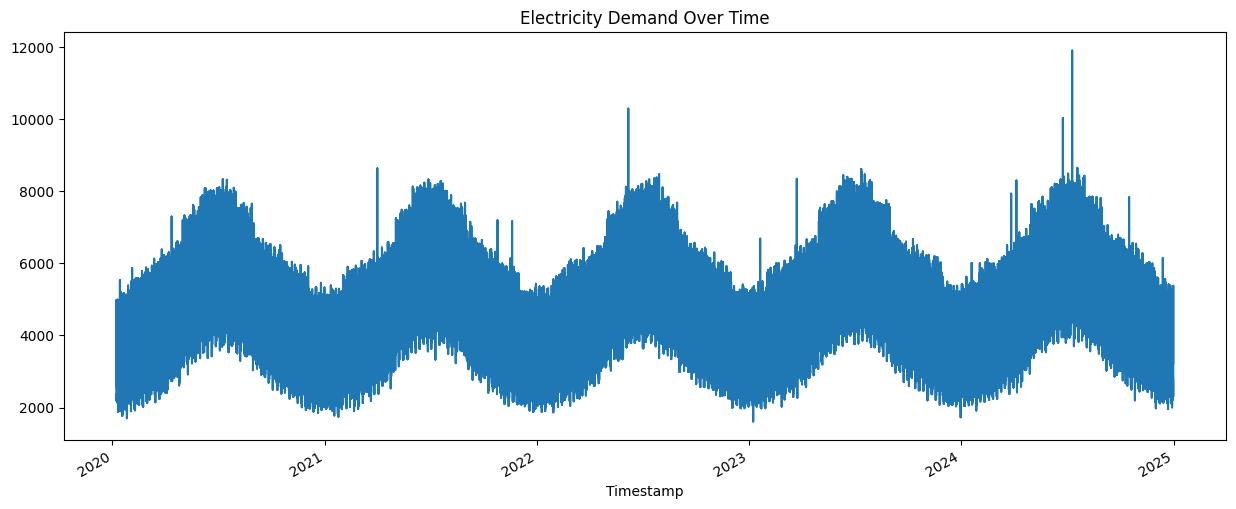

In [ ]:
# Plot raw demand over time

data["Demand"].plot(figsize=(15,6),title="Electricity Demand Over Time")
plt.show()

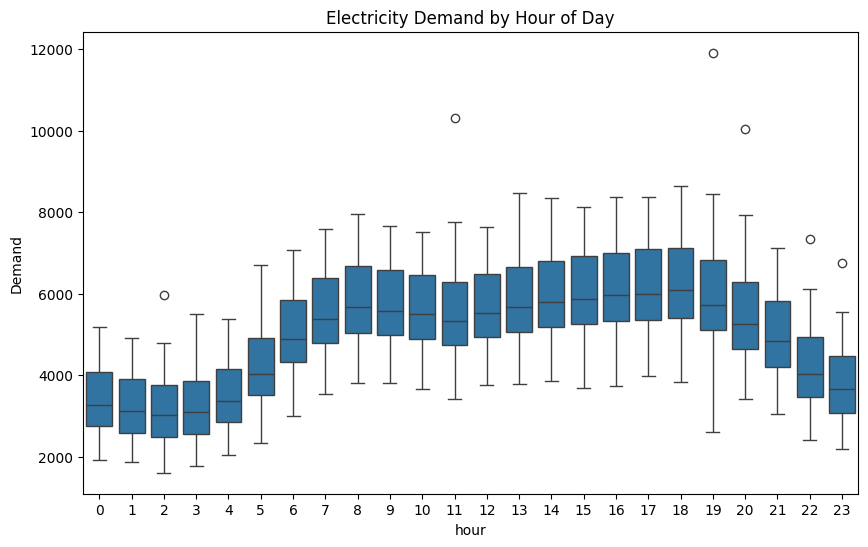

In [ ]:
# Visualize demand by hour of day

plt.figure(figsize=(10,6))
sns.boxplot(x="hour",y="Demand",data=data)
plt.title("Electricity Demand by Hour of Day")
plt.show()

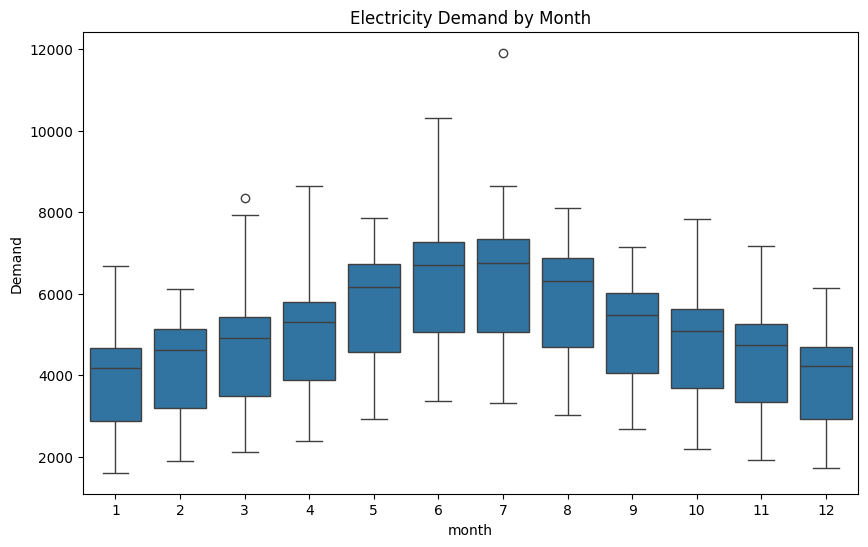

In [ ]:
# Visualize demand by month
plt.figure(figsize=(10,6))
sns.boxplot(x="month",y="Demand",data=data)
plt.title("Electricity Demand by Month")
plt.show()

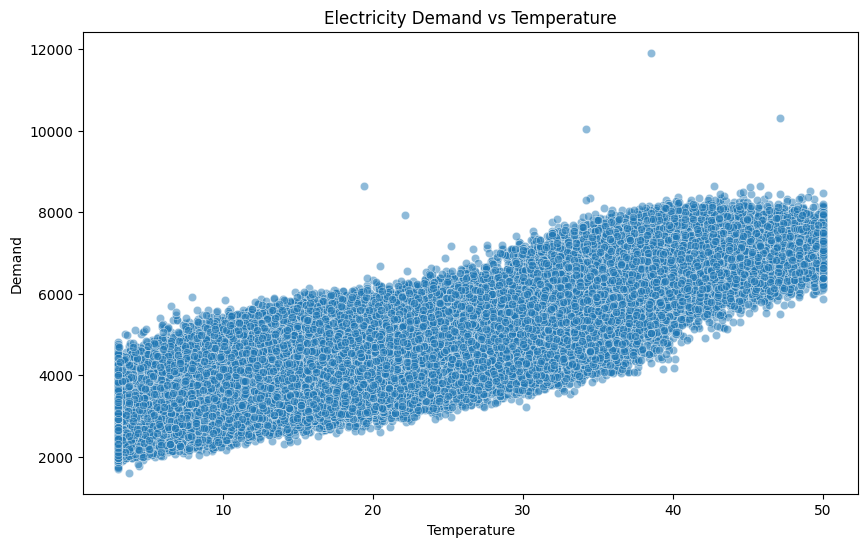

In [ ]:
# Scatter plot of demand vs temperature
plt.figure(figsize=(10,6))
sns.scatterplot(x="Temperature",y="Demand",data=data,alpha=0.5)
plt.title("Electricity Demand vs Temperature")
plt.show()

In [ ]:
# Correlation Matrix
data.corr()

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,Demand_lag_168hr,Demand_rolling_mean_24hr,Demand_rolling_std_24hr
hour,1.000000,-0.000016,0.000049,0.000031,0.000046,0.000047,0.000050,-0.000052,0.051780,-0.293494,0.396024,0.395997,0.395877,0.000068,0.007054
dayofweek,-0.000016,1.000000,0.000954,-0.001175,0.000958,0.000085,0.002458,0.790574,-0.001146,-0.002293,-0.127306,-0.000164,-0.127258,-0.096616,-0.039547
month,0.000049,0.000954,1.000000,-0.008779,0.996483,0.971873,0.971293,-0.001415,-0.013812,0.597465,0.030524,0.038681,0.085776,0.055811,-0.008877
year,0.000031,-0.001175,-0.008779,1.000000,-0.009323,-0.020075,-0.007391,0.000861,-0.005007,-0.000686,0.046549,0.046322,0.046461,0.074883,-0.000239
dayofyear,0.000046,0.000958,0.996483,-0.009323,1.000000,0.973513,0.968179,-0.001222,-0.016741,0.596764,0.028316,0.036487,0.083716,0.052277,-0.011873
weekofyear,0.000047,0.000085,0.971873,-0.020075,0.973513,1.000000,0.947422,0.000046,-0.025475,0.596432,0.021480,0.028932,0.076533,0.040704,-0.022766
Quarter,0.000050,0.002458,0.971293,-0.007391,0.968179,0.947422,1.000000,0.000935,-0.011099,0.614181,0.033115,0.041402,0.087937,0.060094,-0.003829
is_weekend,-0.000052,0.790574,-0.001415,0.000861,-0.001222,0.000046,0.000935,1.000000,-0.001302,-0.001390,-0.160356,-0.047980,-0.160288,-0.162730,-0.145011
Temperature,0.051780,-0.001146,-0.013812,-0.005007,-0.016741,-0.025475,-0.011099,-0.001302,1.000000,0.001481,0.828217,0.804474,0.797218,0.772274,0.568972
Humidity,-0.293494,-0.002293,0.597465,-0.000686,0.596764,0.596432,0.614181,-0.001390,0.001481,1.000000,-0.066211,-0.077768,-0.031038,0.069179,0.002439


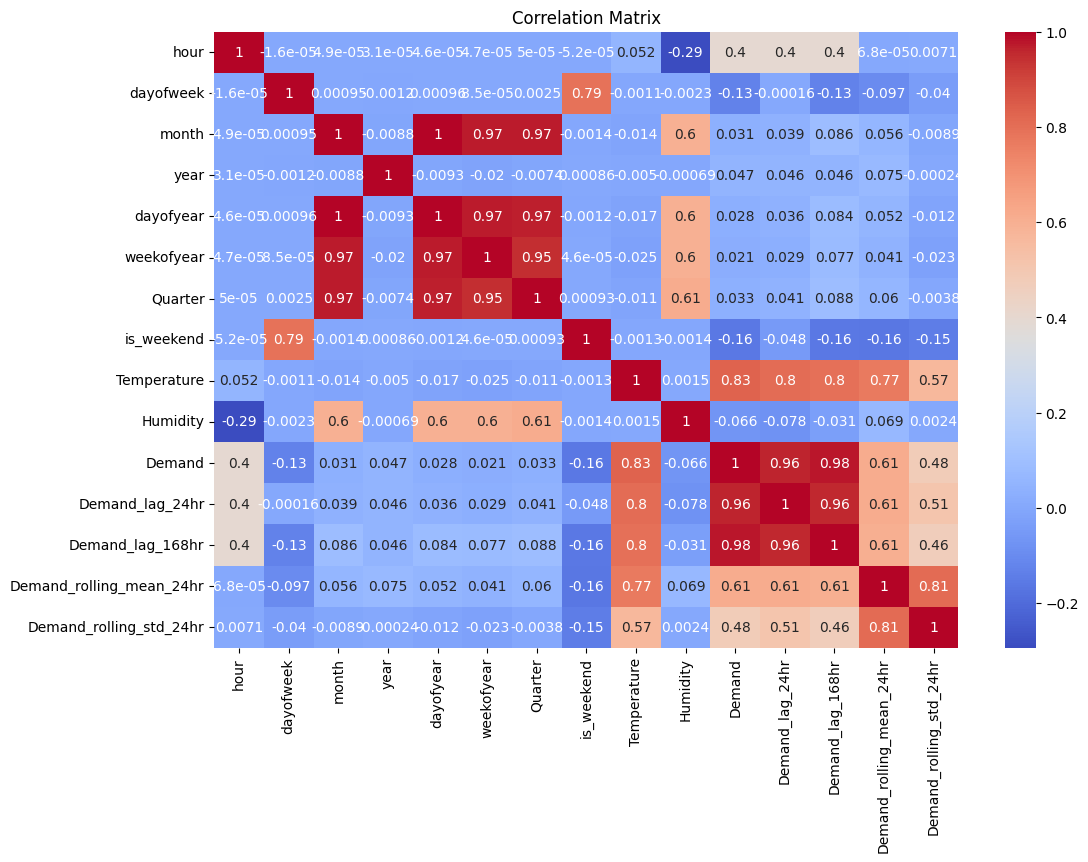

In [ ]:
# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Prediction model
Y=data["Demand"]

In [ ]:
X=data.drop("Demand",axis=1)

In [ ]:
Y

,Demand
Timestamp,
2020-01-08,2363.060115
2020-01-08,2282.558766
2020-01-08,2193.324174
2020-01-08,2208.724679
2020-01-08,2402.611018
...,...
2024-12-31,4689.693109
2024-12-31,4331.249224
2024-12-31,4015.979957


In [ ]:
X

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand_lag_24hr,Demand_lag_168hr,Demand_rolling_mean_24hr,Demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2216.875986,2457.119872,3857.890516,1007.130968
2020-01-08,1,2,1,2020,8,2,1,0,4.433666,61.209727,2400.102433,2269.904712,3852.992863,1014.785101
2020-01-08,2,2,1,2020,8,2,1,0,5.000529,63.868618,2493.107375,2215.640403,3840.501897,1033.916351
2020-01-08,3,2,1,2020,8,2,1,0,4.253477,44.603210,2241.451559,2174.232413,3839.138277,1036.136212
2020-01-08,4,2,1,2020,8,2,1,0,5.966044,85.921008,2406.161001,2472.453006,3838.990361,1036.349905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,5102.077310,5105.730509,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4187.844204,4673.672173,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,3859.260701,3856.359014,4052.475170,977.565114


In [ ]:
# Splitting the data into training and testing

X_train=X.loc[:"2023-12-31"]

In [ ]:
X_train

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand_lag_24hr,Demand_lag_168hr,Demand_rolling_mean_24hr,Demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2216.875986,2457.119872,3857.890516,1007.130968
2020-01-08,1,2,1,2020,8,2,1,0,4.433666,61.209727,2400.102433,2269.904712,3852.992863,1014.785101
2020-01-08,2,2,1,2020,8,2,1,0,5.000529,63.868618,2493.107375,2215.640403,3840.501897,1033.916351
2020-01-08,3,2,1,2020,8,2,1,0,4.253477,44.603210,2241.451559,2174.232413,3839.138277,1036.136212
2020-01-08,4,2,1,2020,8,2,1,0,5.966044,85.921008,2406.161001,2472.453006,3838.990361,1036.349905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31,19,6,12,2023,365,52,4,1,6.721774,46.627264,3894.908251,3840.654680,3597.790591,879.089476
2023-12-31,20,6,12,2023,365,52,4,1,7.557696,58.505012,3797.287793,4122.218903,3599.126925,879.430235
2023-12-31,21,6,12,2023,365,52,4,1,3.000000,48.001079,3280.602315,3307.887152,3604.785551,877.726873


In [ ]:
Y_train=Y.loc[:"2023-12-31"]    # 80% for training

In [ ]:
Y_train

,Demand
Timestamp,
2020-01-08,2363.060115
2020-01-08,2282.558766
2020-01-08,2193.324174
2020-01-08,2208.724679
2020-01-08,2402.611018
...,...
2023-12-31,4185.721624
2023-12-31,3829.359810
2023-12-31,3416.409325


In [ ]:
X_test=X.loc["2024-01-01":]  # 20% for testing

In [ ]:
X_test

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand_lag_24hr,Demand_lag_168hr,Demand_rolling_mean_24hr,Demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,
2024-01-01,0,0,1,2024,1,1,1,0,3.000000,65.297046,2373.967493,2752.003113,3626.185642,856.204515
2024-01-01,1,0,1,2024,1,1,1,0,3.000000,69.068654,2328.972904,2419.747602,3640.380403,836.357296
2024-01-01,2,0,1,2024,1,1,1,0,3.000000,80.885372,1729.176090,2292.834087,3669.813854,776.458065
2024-01-01,3,0,1,2024,1,1,1,0,7.788675,66.501527,2257.337352,2507.704476,3685.801618,749.595470
2024-01-01,4,0,1,2024,1,1,1,0,6.607828,57.858109,2516.948873,2690.933257,3692.926651,738.736316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,5102.077310,5105.730509,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4187.844204,4673.672173,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,3859.260701,3856.359014,4052.475170,977.565114


In [ ]:
Y_test=Y.loc["2024-01-01":]

In [ ]:
Y_test.head()

,Demand
Timestamp,
2024-01-01,2720.606072
2024-01-01,2669.647167
2024-01-01,2435.578924
2024-01-01,2641.043699
2024-01-01,2687.949643


In [ ]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(34896, 14)
(34896,)
(8784, 14)
(8784,)


In [ ]:
# XGBoost for forcasting
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

In [ ]:
 # Initialize and train the model

model_xgb=XGBRegressor(n_estimators=1000,early_stopping_rounds=50,learning_rate=0.01,random_state=42,objective="reg:squarederror")

In [ ]:
model_xgb.fit(X_train,Y_train,eval_set=[(X_train,Y_train),(X_test,Y_test)],verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Make Predictions

predictions_xgb=model_xgb.predict(X_test)

In [ ]:
# Evaluating the model

rmse_xgb=np.sqrt(mean_squared_error(Y_test,predictions_xgb))
mae_xgb=mean_absolute_error(Y_test,predictions_xgb)

In [ ]:
print("RMSE:",rmse_xgb)
print("MAE:",mae_xgb)

RMSE: 175.97572375462272
MAE: 123.989929225497


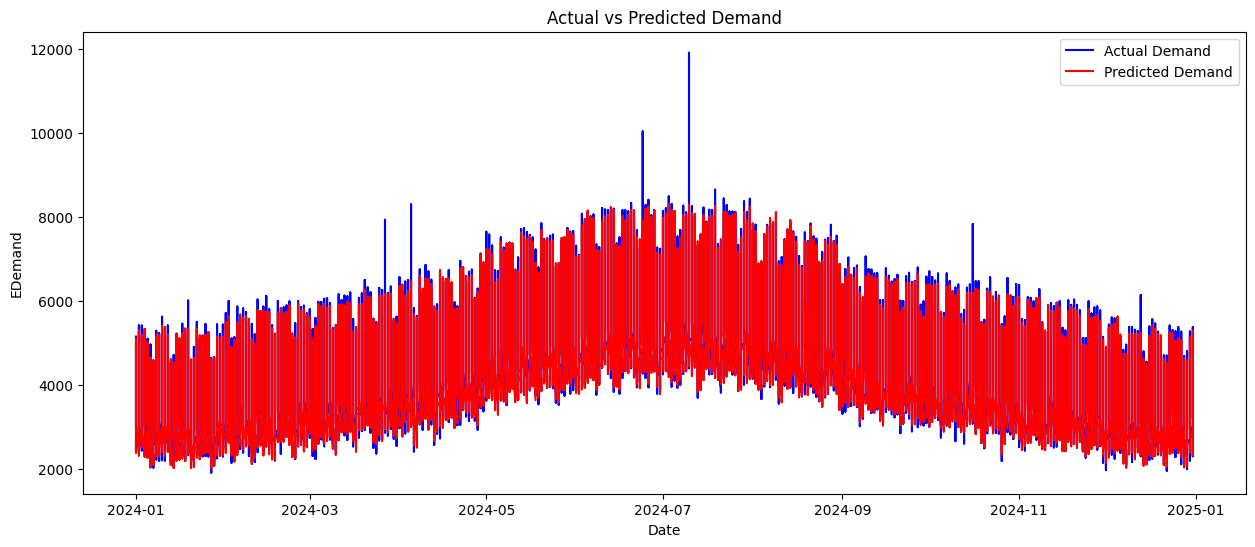

In [ ]:
# Visualize the prediction

plt.figure(figsize=(15,6))
plt.plot(Y_test.index,Y_test.values,label="Actual Demand",color="Blue")
plt.plot(Y_test.index,predictions_xgb,label="Predicted Demand",color="Red")
plt.title("Actual vs Predicted Demand")
plt.xlabel("Date")
plt.ylabel("EDemand")
plt.legend()
plt.show()


In [ ]:
# Save the model
import joblib
joblib.dump(model_xgb,"electricity_xgb_prediction_model.pkl")

['electricity_xgb_prediction_model.pkl']